In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv")
df

,ds,Airports,Class,y
0,1989-07-10,ADL-PER,Business,193
1,1989-07-17,ADL-PER,Business,254
2,1989-07-24,ADL-PER,Business,185
3,1989-07-31,ADL-PER,Business,254
4,1989-08-07,ADL-PER,Business,191
...,...,...,...,...
7402,1992-10-19,SYD-PER,First,203
7403,1992-10-26,SYD-PER,First,137
7404,1992-11-02,SYD-PER,First,161
7405,1992-11-09,SYD-PER,First,155


## 3 way to change column type 
### first way:


In [3]:
df = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv", parse_dates=["ds"])
print(df["ds"].dtype)

datetime64[ns]


### second way:

In [4]:
df_test = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv")
df_test["ds"] = pd.to_datetime(df_test["ds"] , format = "%Y-%M-%d")
print(df_test["ds"].dtype)

datetime64[ns]


### third way: custom parser

In [5]:
df_test = pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv" , parse_dates=["ds"] , date_format = "%Y-%m-%d")
print(df_test["ds"].dtype)

datetime64[ns]


In [6]:
melsyd_economy = (
    pd.read_csv("C:\\Users\\dell\\forecasting\\ansett.csv" , parse_dates=["ds"])
    .loc[lambda x: (x["Airports"] == "MEL-SYD")
        & (x["Class"] == "Economy")]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
).reset_index().drop(columns = ["index"])

melsyd_economy

,ds,unique_id,Class,y
0,1987-06-22,MEL-SYD,Economy,20.167
1,1987-06-29,MEL-SYD,Economy,20.161
2,1987-07-06,MEL-SYD,Economy,19.993
3,1987-07-13,MEL-SYD,Economy,20.986
4,1987-07-20,MEL-SYD,Economy,20.497
...,...,...,...,...
277,1992-10-19,MEL-SYD,Economy,28.837
278,1992-10-26,MEL-SYD,Economy,26.548
279,1992-11-02,MEL-SYD,Economy,27.279
280,1992-11-09,MEL-SYD,Economy,27.306


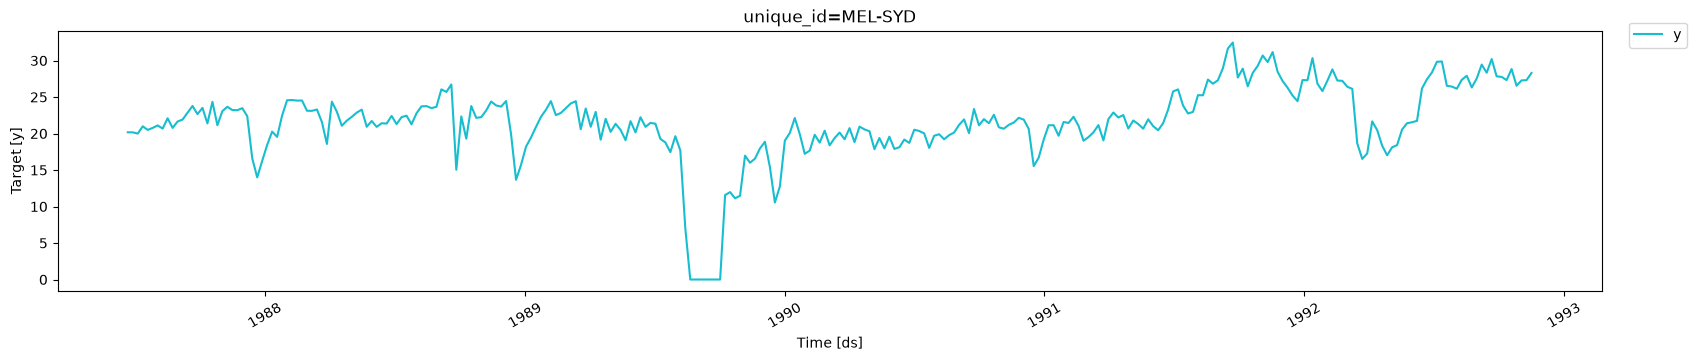

In [7]:
from utilsforecast.plotting import plot_series

plot_series(
    df = melsyd_economy,
    id_col = "unique_id",
    time_col = "ds",
    target_col = "y")



In [8]:
pbs = (
    pd.read_csv("C:\\Users\\dell\\forecasting\\PBS_unparsed.csv", parse_dates=["Month"])
    [["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]
)
pbs

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,A,A01,18228,67877.0
1,1991-08-01,Concessional,Co-payments,A,A01,15327,57011.0
2,1991-09-01,Concessional,Co-payments,A,A01,14775,55020.0
3,1991-10-01,Concessional,Co-payments,A,A01,15380,57222.0
4,1991-11-01,Concessional,Co-payments,A,A01,14371,52120.0
...,...,...,...,...,...,...,...
67591,2008-02-01,General,Safety net,Z,Z,135,1591.0
67592,2008-03-01,General,Safety net,Z,Z,15,276.0
67593,2008-04-01,General,Safety net,Z,Z,11,165.0
67594,2008-05-01,General,Safety net,Z,Z,21,278.0


In [9]:
total_cost = (pbs
              .loc[pbs["ATC2"] == "A10"]
              .drop(columns= ["ATC1" , "ATC2"])
              .groupby("Month" , as_index=False)
              .agg({"Cost" : "sum"})
              .assign(Cost=lambda x: (x["Cost"] / 1e6).round(2))
              .rename(columns= {"Cost" : "Total cost (milions)"})
)

total_cost

,Month,Total cost (milions)
0,1991-07-01,3.53
1,1991-08-01,3.18
2,1991-09-01,3.25
3,1991-10-01,3.61
4,1991-11-01,3.57
...,...,...
199,2008-02-01,21.65
200,2008-03-01,18.26
201,2008-04-01,23.11
202,2008-05-01,22.91


| code |  meaning  | example |
|------|-----------|---------|
| %b  | abbreviated month name | Jan |
| %B  | Full month name | January |
| %m  | Month number | 01 ,02 |
| %Y  | 4 digit year | 2026 |
| %y  | 2 digit year | 26 |
| %d  | day of month | 01 ,02 |
| %a | abbreviated weekday name | Mon |
| %A | Full weekday name | Monday |


In [10]:
df = total_cost.assign(
    Month_name = total_cost["Month"].dt.strftime("%b"),
    Year = total_cost["Month"].dt.year,
    Month_num = total_cost["Month"].dt.month
)
df

,Month,Total cost (milions),Month_name,Year,Month_num
0,1991-07-01,3.53,Jul,1991,7
1,1991-08-01,3.18,Aug,1991,8
2,1991-09-01,3.25,Sep,1991,9
3,1991-10-01,3.61,Oct,1991,10
4,1991-11-01,3.57,Nov,1991,11
...,...,...,...,...,...
199,2008-02-01,21.65,Feb,2008,2
200,2008-03-01,18.26,Mar,2008,3
201,2008-04-01,23.11,Apr,2008,4
202,2008-05-01,22.91,May,2008,5


In [11]:
unique_years = df["Year"].unique()
unique_years

array([1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008], dtype=int32)

In [12]:
import seaborn as sns

year_palette = sns.color_palette("husl", n_colors=len(unique_years))

C:\Users\dell\AppData\Local\Temp\ipykernel_23708\958864624.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


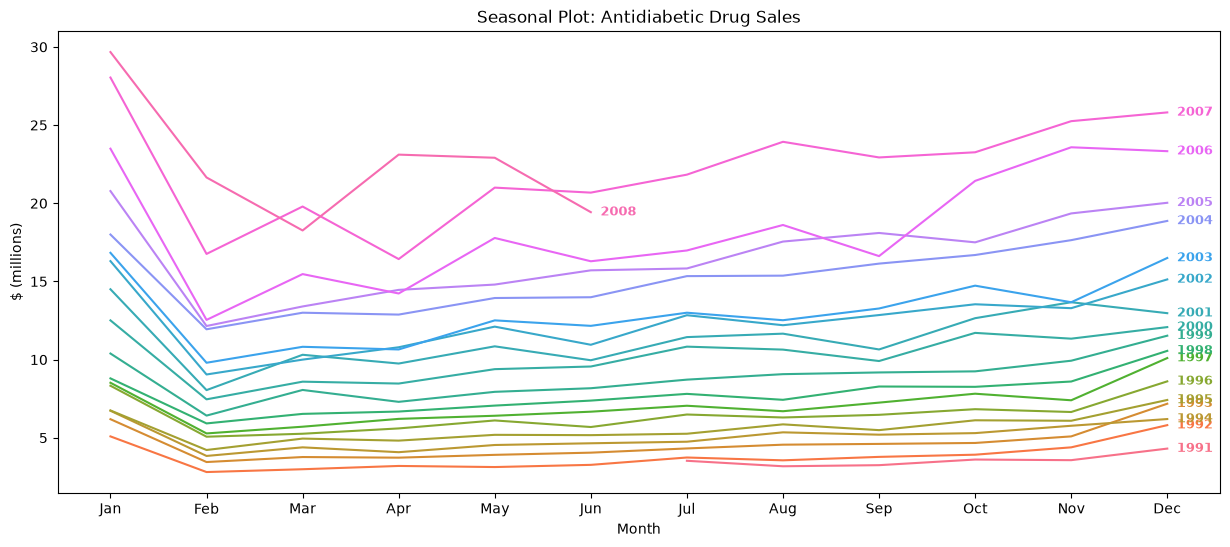

In [13]:
import seaborn as sns
import matplotlib.pylab as plt 

fig , ax = plt.subplots(figsize=(15, 6))
sns.lineplot( data= df , x="Month_num", y="Total cost (milions)" ,hue= "Year" , palette= year_palette ,legend= False , ax= ax )

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ],
)

min_year = unique_years.min()
for year, subset in df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Total cost (milions)"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year), ha="left", va="center", fontsize=9, weight="bold", color=color)

fig.show()


In [14]:
vic_elc_df = pd.read_csv("C:\\Users\\dell\\forecasting\\vic_elec.csv",parse_dates=["ds"])
vic_elc_df

,ds,unique_id,y,Holiday
0,2012-01-01 00:00:00,Demand,4382.825174,True
1,2012-01-01 00:30:00,Demand,4263.365526,True
2,2012-01-01 01:00:00,Demand,4048.966046,True
3,2012-01-01 01:30:00,Demand,3877.563330,True
4,2012-01-01 02:00:00,Demand,4036.229746,True
...,...,...,...,...
105199,2014-12-31 21:30:00,Temperature,19.000000,False
105200,2014-12-31 22:00:00,Temperature,18.500000,False
105201,2014-12-31 22:30:00,Temperature,17.700000,False
105202,2014-12-31 23:00:00,Temperature,17.300000,False


In [15]:
vic_elc_demand = vic_elc_df[vic_elc_df["unique_id"] == "Demand"]
vic_elc_demand

,ds,unique_id,y,Holiday
0,2012-01-01 00:00:00,Demand,4382.825174,True
1,2012-01-01 00:30:00,Demand,4263.365526,True
2,2012-01-01 01:00:00,Demand,4048.966046,True
3,2012-01-01 01:30:00,Demand,3877.563330,True
4,2012-01-01 02:00:00,Demand,4036.229746,True
...,...,...,...,...
52597,2014-12-31 21:30:00,Demand,3873.448714,False
52598,2014-12-31 22:00:00,Demand,3791.637322,False
52599,2014-12-31 22:30:00,Demand,3724.835666,False
52600,2014-12-31 23:00:00,Demand,3761.886854,False


C:\Users\dell\AppData\Local\Temp\ipykernel_23708\3415217878.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


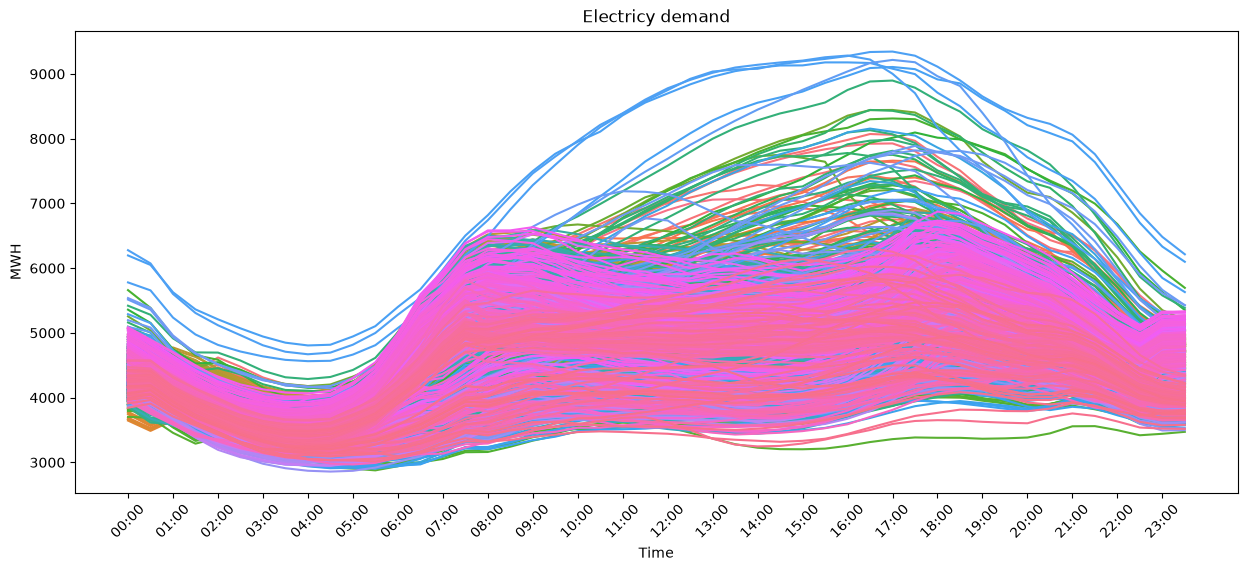

In [16]:
import seaborn as sns

df = vic_elc_demand.assign(
    hour_min = lambda x : x["ds"].dt.strftime("%H:%M"),
    day = lambda x : x["ds"].dt.date
)

fig , ax = plt.subplots(figsize=(15, 6))
sns.lineplot(data= df , x="hour_min" , y = "y", hue="day" , palette="husl", legend=False , ax =ax)

ax.set(title="Electricy demand",
       xlabel = "Time",
       ylabel = "MWH"
)

unique_ticks = df["hour_min"].unique()
ticks = range(0, len(unique_ticks), 2)
ticklabels = unique_ticks[::2]
ax.set_xticks(ticks, labels=ticklabels, rotation=45)
fig.show()


C:\Users\dell\AppData\Local\Temp\ipykernel_23708\1563768250.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


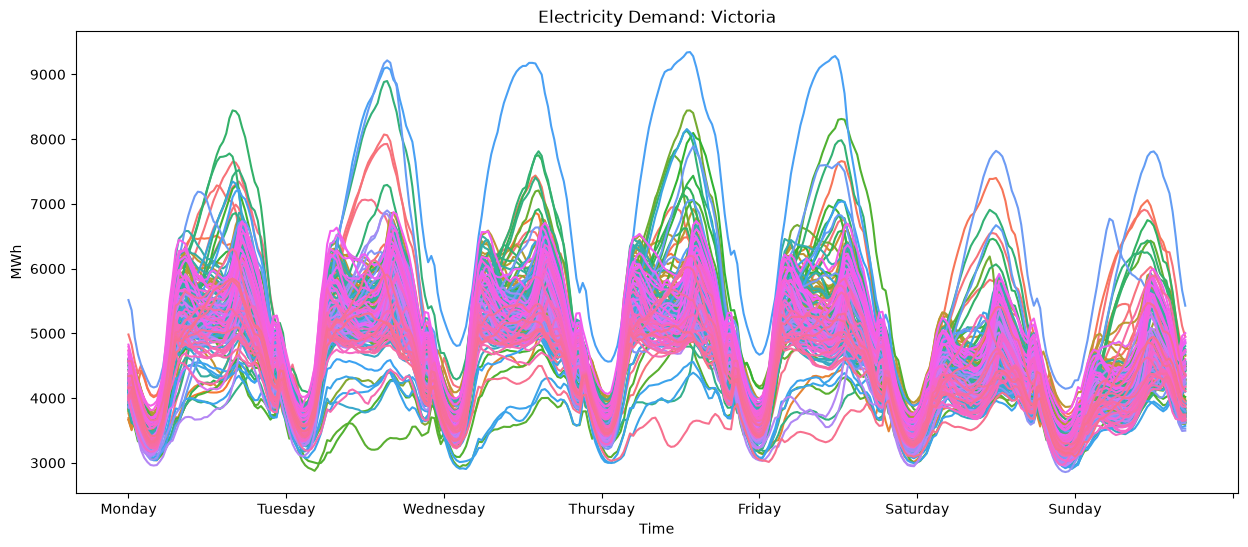

In [17]:
df = (
    vic_elc_demand
    .loc[lambda x: x["ds"].between("2012-01-02", "2014-12-28 23:59")]
    .assign(
        day_of_week=lambda x: x["ds"].dt.day_name(),
        week=lambda x: x["ds"].dt.to_period("W").dt.start_time,
    )
)
unique_weeks = df["week"].unique()
palette = sns.color_palette("husl", n_colors=len(unique_weeks))
color_map = dict(zip(unique_weeks, palette))
 
fig, ax = plt.subplots(figsize = (15,6))

for week, df_week in df.groupby("week"):
    df_week.plot(x="day_of_week", y="y",ax=ax, color=color_map[week])

ax.get_legend().remove()
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)
fig.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_23708\3352597887.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


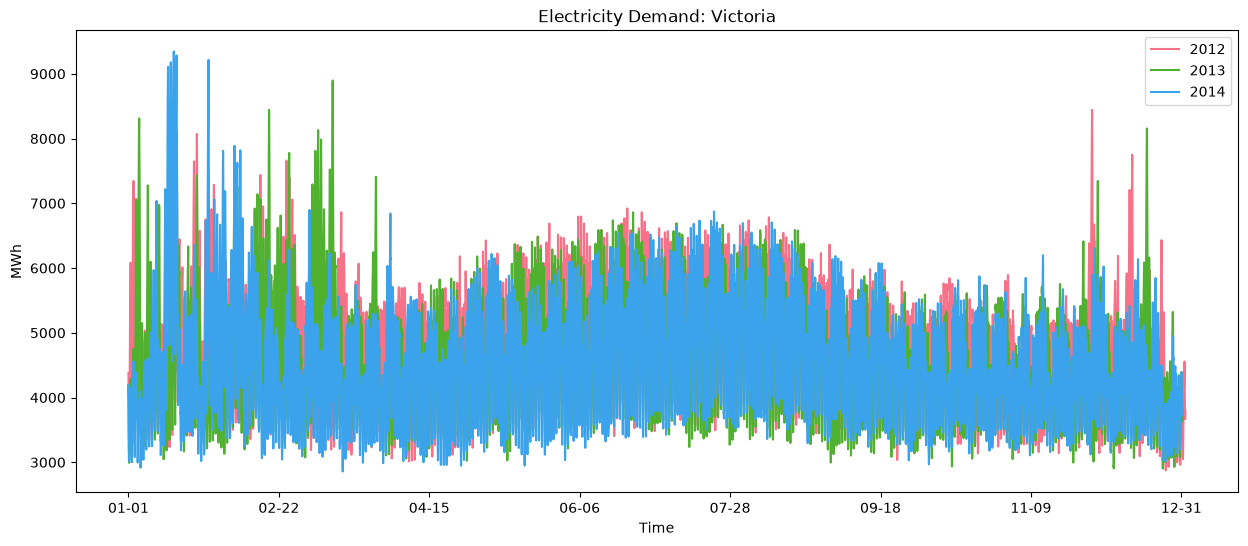

In [18]:
df = vic_elc_demand.assign(
    day_of_year=lambda x: x["ds"].dt.strftime("%m-%d"),
    year=lambda x: x["ds"].dt.year,
)
palette = sns.color_palette("husl", n_colors=df["year"].nunique())
fig, ax = plt.subplots(figsize = (15,6))

for i_year, (year, df_year) in enumerate(df.groupby("year")):
    df_year.plot(x="day_of_year", y="y", ax=ax, label=str(year), color=palette[i_year])
    
ax.set(
    title="Electricity Demand: Victoria",
    ylabel="MWh",
    xlabel="Time")

fig.show()